In [1]:
# impport libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [3]:
dataset_path = r"C:\Users\kanch\Interships\UnifidedMento\Projects\Animal Classification\dataset"

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

class_names = train_data.class_names
print("Classes:", class_names)

Found 1944 files belonging to 15 classes.
Using 1556 files for training.
Found 1944 files belonging to 15 classes.
Using 388 files for validation.
Classes: ['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse', 'Kangaroo', 'Lion', 'Panda', 'Tiger', 'Zebra']


In [5]:
# Normalize the pixel values to [0, 1]
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map(lambda x, y: (normalization_layer(x), y))

In [6]:
# Build CNN Model
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
    
])

c:\Users\kanch\Interships\interns\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
# Train the model
history = model.fit(train_data, validation_data=val_data, epochs=20)


Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 206ms/step - accuracy: 0.8194 - loss: 0.5780 - val_accuracy: 0.7216 - val_loss: 1.3575
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - accuracy: 0.8631 - loss: 0.4553 - val_accuracy: 0.7345 - val_loss: 1.3394
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.8753 - loss: 0.3792 - val_accuracy: 0.7345 - val_loss: 1.3223
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - accuracy: 0.9055 - loss: 0.3244 - val_accuracy: 0.7552 - val_loss: 1.2979
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.9030 - loss: 0.3217 - val_accuracy: 0.7680 - val_loss: 1.3441
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - accuracy: 0.9075 - loss: 0.3151 - val_accuracy: 0.7603 - val_loss: 1.3635
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 203ms/step - accuracy: 0.9203 - loss: 0.2564 - val_accuracy: 0.7680 - val_loss: 1.2755
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 203ms/step - accuracy: 0.9081 - loss: 0.2995 - val_accu

In [12]:
# Evaluate the model
test_loss, test_acc = model.evaluate(val_data)
print(f"Test Accuracy: {test_acc:.2f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7809 - loss: 1.6919
Test Accuracy: 0.78


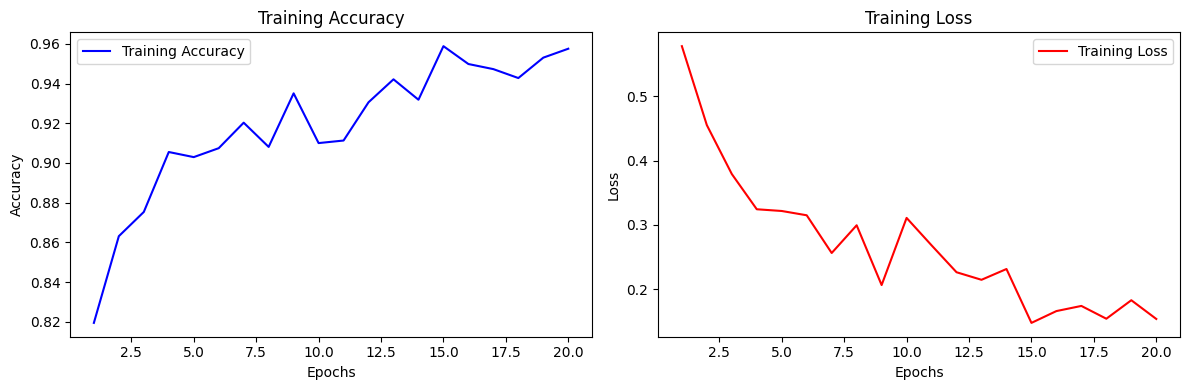

In [13]:
# plot accuracy and loss
acc = history.history['accuracy']
loss = history.history['loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r-', label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()          

In [14]:
# Save the model
model.save('animal_classification_model.h5')

In [15]:
# Prediction Function
import numpy as np
from tensorflow.keras.preprocessing import image
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions)]
    
    
    return f"Predicted Class: {predicted_class}"

In [18]:
predict_image(r"C:\Users\kanch\Interships\UnifidedMento\Projects\Animal Classification\dataset\Deer\Deer_10.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


'Predicted Class: Deer'